# PHI NER — Error Analysis

A model with 99% F1 sounds great — but the 1% it misses could be the most dangerous cases (SSNs, full addresses). This notebook categorizes every error to understand **what fails and why**.

**What it does:**
1. Runs the best model on the full test set
2. Extracts entity spans from both true and predicted BIO tags
3. Categorizes false negatives (missed PHI) and false positives (incorrect redactions)
4. Analyzes error correlation with text length, entity density, and position
5. Produces actionable insights for improving the model or training data

**Runtime**: CPU is sufficient (no training, just inference)

**Depends on**: A trained model — either from notebook 01 (published to Weave) or local `models/` directory

**Estimated time**: ~10 minutes

In [3]:
!pip install -q transformers wandb weave seqeval matplotlib numpy pandas

In [4]:
import wandb, weave, json, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter, defaultdict
from pathlib import Path
from google.colab import userdata
from transformers import pipeline as hf_pipeline

try: wandb.login(key=userdata.get("WANDB_API_KEY"))
except: wandb.login()
weave.init("mobile-rag-firewall")

LABEL_LIST = ["O", "B-NAME", "I-NAME", "B-ADDRESS", "I-ADDRESS"]
ID_TO_LABEL = {i: l for i, l in enumerate(LABEL_LIST)}

test_ds = weave.ref("phi-ner-test:latest").get()
test_data = test_ds.rows
print(f"Test: {len(test_data)} examples")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ricardo-morales-b to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave


Test: 1861 examples


In [5]:
# Load model — try local first, then W&B artifact
model_path = "models/distilbert_42/best"
if not Path(model_path).exists():
    model_path = "models/distilbert/best"
if not Path(model_path).exists():
    # Pull from W&B artifact
    print("Pulling model from W&B artifact...")
    run = wandb.init(project="mobile-rag-firewall", job_type="pull-model")
    artifact = run.use_artifact("phi-ner-model:latest")
    model_path = artifact.download(root="ner_model_cache")
    run.finish()

ner = hf_pipeline("ner", model=model_path, tokenizer=model_path, aggregation_strategy="simple")
print(f"Loaded model from {model_path}")

Pulling model from W&B artifact...


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave
wandb: Downloading large artifact 'phi-ner-model:latest', 253.87MB. 5 files...
wandb:   5 of 5 files downloaded.  
Done. 00:00:24.8 (10.2MB/s)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loaded model from ner_model_cache


## Run Predictions + Extract Entities

Run the model on every test example and convert BIO tag sequences back to entity spans.

`extract_entities()` converts tags like `[O, B-NAME, I-NAME, I-NAME, O]` into structured entity spans like `[{type: "NAME", text: "Adah626 Flo729 Klein929", start: 1, end: 4}]`.

For each example we store the true entities, predicted entities, and the raw text for context in error analysis.

In [6]:
def extract_entities(tags, tokens):
    """Convert BIO tags to entity spans: [(type, text, start_idx, end_idx)]."""
    entities, current = [], None
    for i, tag in enumerate(tags):
        if tag.startswith("B-"):
            if current: entities.append(current)
            current = {"type": tag[2:], "start": i, "end": i+1, "tokens": [tokens[i]]}
        elif tag.startswith("I-") and current and tag[2:] == current["type"]:
            current["end"] = i+1
            current["tokens"].append(tokens[i])
        else:
            if current: entities.append(current)
            current = None
    if current: entities.append(current)
    return [{"type": e["type"], "text": " ".join(e["tokens"]),
             "start": e["start"], "end": e["end"]} for e in entities]

# Run predictions on all test examples
results = []
for ex in test_data:
    tokens = ex["tokens"]
    true_tags = ex["ner_tags"]
    text = " ".join(tokens)

    # Get model predictions
    preds = ner(text)
    # Map predictions back to token-level (simplified: use entity_group)
    pred_entities = [{"type": p["entity_group"], "text": p["word"].strip(),
                      "score": p["score"]} for p in preds if p["entity_group"] != "O"]

    true_entities = extract_entities(true_tags, tokens)

    results.append({
        "tokens": tokens, "text": text,
        "true_tags": true_tags, "true_entities": true_entities,
        "pred_entities": pred_entities, "n_tokens": len(tokens),
    })

print(f"Processed {len(results)} examples")
total_true = sum(len(r["true_entities"]) for r in results)
total_pred = sum(len(r["pred_entities"]) for r in results)
print(f"True entities: {total_true}, Predicted entities: {total_pred}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 1861 examples
True entities: 1625, Predicted entities: 1732


## Entity-Level Confusion + Error Classification

Match predicted entities to true entities by text overlap. Classify each outcome:
- **Correct**: predicted entity overlaps with a true entity of the same type
- **False Negative (FN)**: true entity with no matching prediction — PHI leaked through
- **False Positive (FP)**: predicted entity with no matching true entity — legitimate text incorrectly redacted

FN categories help identify model weaknesses (what PHI it misses).
FP categories help identify over-redaction patterns (what clean text it damages).

The second cell categorizes each error and produces:
- Bar charts of FN/FP categories
- Top 10 examples of each with context for manual inspection

In [7]:
# Match true entities to predicted entities (by text overlap)
false_negatives, false_positives, correct = [], [], []

for r in results:
    true_set = {e["text"].lower() for e in r["true_entities"]}
    pred_set = {e["text"].lower() for e in r["pred_entities"]}

    for e in r["true_entities"]:
        matched = any(e["text"].lower() in p["text"].lower() or p["text"].lower() in e["text"].lower()
                      for p in r["pred_entities"] if p["type"] == e["type"])
        if matched:
            correct.append({**e, "context": r["text"][:100]})
        else:
            false_negatives.append({**e, "context": r["text"][:100], "n_tokens": r["n_tokens"]})

    for p in r["pred_entities"]:
        matched = any(p["text"].lower() in e["text"].lower() or e["text"].lower() in p["text"].lower()
                      for e in r["true_entities"] if e["type"] == p["type"])
        if not matched:
            false_positives.append({**p, "context": r["text"][:100], "n_tokens": r["n_tokens"]})

print(f"Correct: {len(correct)}, FN: {len(false_negatives)}, FP: {len(false_positives)}")

# Confusion summary
print(f"\nFalse Negatives by type:")
fn_types = Counter(e["type"] for e in false_negatives)
for t, c in fn_types.most_common(): print(f"  {t}: {c}")

print(f"\nFalse Positives by type:")
fp_types = Counter(e["type"] for e in false_positives)
for t, c in fp_types.most_common(): print(f"  {t}: {c}")

Correct: 1532, FN: 93, FP: 264

False Negatives by type:
  ADDRESS: 65
  NAME: 28

False Positives by type:
  ADDRESS: 221
  NAME: 43


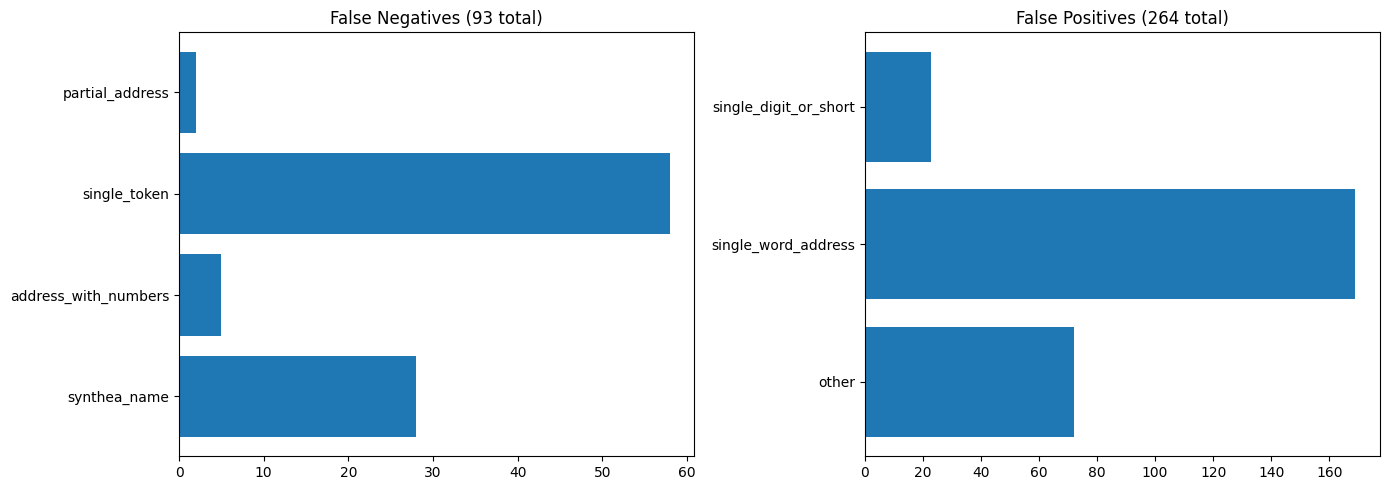


--- Top 10 False Negatives ---
  [NAME] "Riley817 Jarod376 Spinka232:" | cat=synthea_name | ctx=Medical record for Riley817 Jarod376 Spinka232: Date of birt...
  [ADDRESS] "915 Witting Annex Apt 45" | cat=address_with_numbers | ctx=-30 : Chloride [Moles/volume] in Serum or Plasma 106.3 mmol/...
  [ADDRESS] "EDMONDS" | cat=single_token | ctx=3) : Encounter at SWEDISH EDMONDS : Encounter for Allergic d...
  [ADDRESS] "EDMONDS" | cat=single_token | ctx=3) : Encounter at SWEDISH EDMONDS : Encounter for Allergic d...
  [ADDRESS] "EDMONDS" | cat=single_token | ctx=3) : Encounter at SWEDISH EDMONDS : Encounter for Allergic d...
  [ADDRESS] "EDMONDS" | cat=single_token | ctx=3) : Encounter at SWEDISH EDMONDS : Encounter for Allergic d...
  [ADDRESS] "EDMONDS" | cat=single_token | ctx=3) : Encounter at SWEDISH EDMONDS : Encounter for Allergic d...
  [ADDRESS] "EDMONDS" | cat=single_token | ctx=3) : Encounter at SWEDISH EDMONDS : Encounter for Allergic d...
  [ADDRESS] "EDMONDS" | cat=single_to

In [8]:
# Categorize false negatives
def categorize_fn(e):
    text = e["text"]
    if len(text.split()) <= 1: return "single_token"
    if re.search(r"\d{2,}", text): return "synthea_name" if e["type"] == "NAME" else "address_with_numbers"
    if e["type"] == "NAME" and len(text) < 8: return "short_name"
    if e["type"] == "ADDRESS" and len(text.split()) <= 2: return "partial_address"
    return "other"

def categorize_fp(e):
    text = e["text"]
    if text.strip().isdigit() or len(text.strip()) <= 2: return "single_digit_or_short"
    if re.match(r"^\d+$", text.strip()): return "number_only"
    if text.lower() in {"aspirin","metformin","lisinopril","ibuprofen"}: return "drug_name"
    if re.match(r"\d{4}-\d{2}-\d{2}", text): return "date_pattern"
    if e["type"] == "ADDRESS" and len(text.split()) <= 1: return "single_word_address"
    return "other"

fn_cats = Counter(categorize_fn(e) for e in false_negatives)
fp_cats = Counter(categorize_fp(e) for e in false_positives)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(list(fn_cats.keys()), list(fn_cats.values()))
axes[0].set_title(f"False Negatives ({len(false_negatives)} total)")
axes[1].barh(list(fp_cats.keys()), list(fp_cats.values()))
axes[1].set_title(f"False Positives ({len(false_positives)} total)")
plt.tight_layout()
plt.show()

# Show examples
print("\n--- Top 10 False Negatives ---")
for e in false_negatives[:10]:
    print(f"  [{e['type']}] \"{e['text']}\" | cat={categorize_fn(e)} | ctx={e['context'][:60]}...")

print("\n--- Top 10 False Positives ---")
for e in false_positives[:10]:
    print(f"  [{e['type']}] \"{e['text']}\" | cat={categorize_fp(e)} | ctx={e['context'][:60]}...")

## Error vs Text Properties

Are errors correlated with observable text properties? This helps identify when the model is less reliable:

- **Error rate vs text length**: Do longer responses have more errors? (If yes, recursive chunking quality matters)
- **Error rate vs entity density**: Do text-dense sections (many entities per 100 tokens) cause more confusion?

These plots inform whether the model needs more training data for specific scenarios or whether the chunking strategy needs adjustment.

/tmp/ipykernel_3764/3541981005.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = dens.groupby("density_bin")["has_error"].mean()


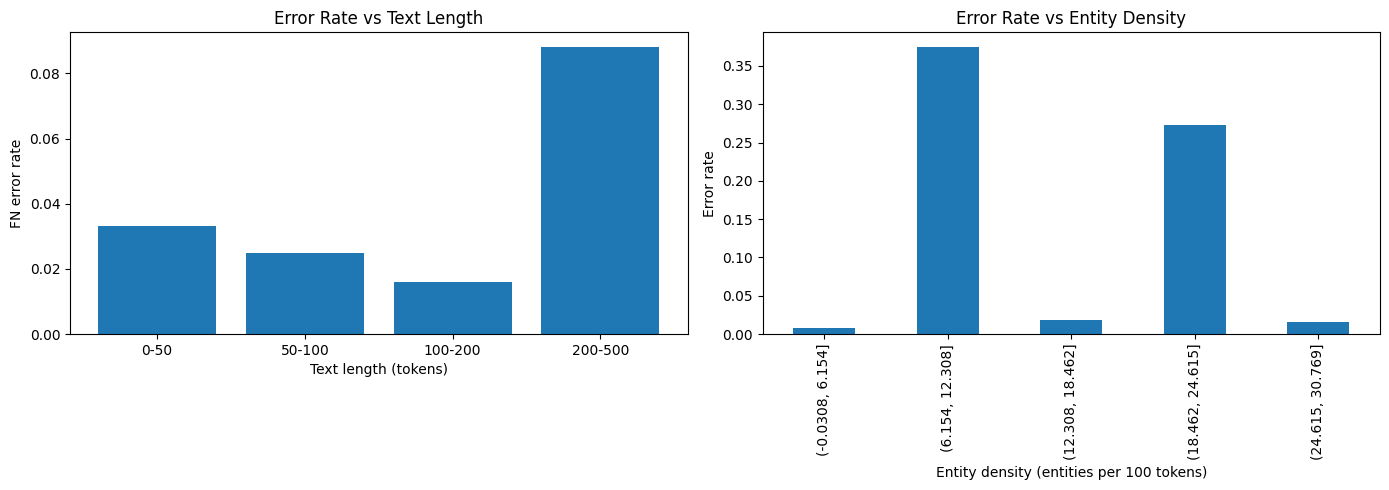

In [9]:
# Error rate vs text length
length_bins = [(0,50,"0-50"), (50,100,"50-100"), (100,200,"100-200"), (200,500,"200-500"), (500,9999,"500+")]
err_by_length = []
for lo, hi, label in length_bins:
    examples = [r for r in results if lo <= r["n_tokens"] < hi]
    if not examples: continue
    n_true = sum(len(r["true_entities"]) for r in examples)
    fn_in_bin = sum(1 for e in false_negatives if lo <= e.get("n_tokens",0) < hi)
    err_rate = fn_in_bin / n_true if n_true > 0 else 0
    err_by_length.append({"bin": label, "error_rate": err_rate, "n_examples": len(examples)})

# Error rate vs entity density
density_data = []
for r in results:
    n_ent = len(r["true_entities"])
    n_tok = r["n_tokens"]
    density = n_ent / max(n_tok, 1) * 100
    has_error = any(e["context"] == r["text"][:100] for e in false_negatives)
    density_data.append({"density": density, "has_error": has_error})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length plot
if err_by_length:
    axes[0].bar([e["bin"] for e in err_by_length], [e["error_rate"] for e in err_by_length])
    axes[0].set_xlabel("Text length (tokens)")
    axes[0].set_ylabel("FN error rate")
    axes[0].set_title("Error Rate vs Text Length")

# Density plot
dens = pd.DataFrame(density_data)
if not dens.empty:
    dens["density_bin"] = pd.cut(dens["density"], bins=5)
    grp = dens.groupby("density_bin")["has_error"].mean()
    grp.plot(kind="bar", ax=axes[1])
    axes[1].set_xlabel("Entity density (entities per 100 tokens)")
    axes[1].set_ylabel("Error rate")
    axes[1].set_title("Error Rate vs Entity Density")

plt.tight_layout()
plt.show()

In [10]:
# Publish analysis to Weave
analysis = {
    "total_examples": len(results),
    "total_true_entities": total_true,
    "total_pred_entities": total_pred,
    "correct": len(correct),
    "false_negatives": len(false_negatives),
    "false_positives": len(false_positives),
    "fn_by_type": dict(fn_types),
    "fp_by_type": dict(fp_types),
    "fn_categories": dict(fn_cats),
    "fp_categories": dict(fp_cats),
}
weave.publish(analysis, name="phi-ner-error-analysis")
print("Published error analysis to Weave.")
print(json.dumps(analysis, indent=2))

weave: 📦 Published to https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave/objects/phi-ner-error-analysis/versions/B9iewIecQHN62Ylwe1HAx1qmYbHSA0jQtOC5gCXFf78


Published error analysis to Weave.
{
  "total_examples": 1861,
  "total_true_entities": 1625,
  "total_pred_entities": 1732,
  "correct": 1532,
  "false_negatives": 93,
  "false_positives": 264,
  "fn_by_type": {
    "NAME": 28,
    "ADDRESS": 65
  },
  "fp_by_type": {
    "NAME": 43,
    "ADDRESS": 221
  },
  "fn_categories": {
    "synthea_name": 28,
    "address_with_numbers": 5,
    "single_token": 58,
    "partial_address": 2
  },
  "fp_categories": {
    "other": 72,
    "single_word_address": 169,
    "single_digit_or_short": 23
  }
}
